# CS596 - Assignment 1: Machine Learning Basics on CIFAR-10

**Bishop's University - Research Topics on Computer Science**

Four classic classifiers implemented in PyTorch and validated on CIFAR-10 with proper
train/validation/test splits and hyperparameter tuning:

- k-Nearest Neighbours
- Linear Support Vector Machine (multiclass hinge loss)
- Linear regression (least-squares, used as a classifier)
- Logistic (softmax) regression

All models run on the GPU when one is available.

In [1]:
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import torchvision, torchvision.transforms as T
import warnings; warnings.filterwarnings("ignore")

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
torch.manual_seed(0); np.random.seed(0)

Device: cuda
GPU: NVIDIA GeForce RTX 3080
VRAM: 10.7 GB


## Load CIFAR-10 and build flat feature vectors

In [2]:
tf = T.Compose([T.ToTensor()])
train_set = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=tf)
test_set  = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=tf)
classes = train_set.classes

# stack into flat tensors (N, 3072), scaled to [0,1]
Xtr_all = torch.stack([img for img, _ in train_set]).view(len(train_set), -1)
ytr_all = torch.tensor(train_set.targets)
Xte = torch.stack([img for img, _ in test_set]).view(len(test_set), -1)
yte = torch.tensor(test_set.targets)

# hold out 5,000 training images as a validation set for tuning
perm = torch.randperm(len(Xtr_all))
val_idx, tr_idx = perm[:5000], perm[5000:]
Xtr, ytr = Xtr_all[tr_idx], ytr_all[tr_idx]
Xval, yval = Xtr_all[val_idx], ytr_all[val_idx]
print("train:", Xtr.shape, "| val:", Xval.shape, "| test:", Xte.shape)

# standardise (fit on training split) for the linear models
mean, std = Xtr.mean(0), Xtr.std(0) + 1e-7
def standardize(X): return (X - mean) / std

accuracies = {}
def accuracy(pred, y): return (pred.cpu() == y.cpu()).float().mean().item()

  0%|          | 0.00/170M [00:00<?, ?B/s]

  0%|          | 229k/170M [00:00<01:26, 1.96MB/s]

  1%|          | 1.34M/170M [00:00<00:24, 6.97MB/s]

  2%|▏         | 3.41M/170M [00:00<00:12, 12.9MB/s]

  3%|▎         | 5.47M/170M [00:00<00:10, 15.8MB/s]

...

 98%|█████████▊| 167M/170M [00:10<00:00, 15.9MB/s]

 99%|█████████▊| 168M/170M [00:11<00:00, 16.0MB/s]

100%|█████████▉| 170M/170M [00:11<00:00, 16.2MB/s]

100%|██████████| 170M/170M [00:11<00:00, 15.2MB/s]

train: torch.Size([45000, 3072]) | val: torch.Size([5000, 3072]) | test: torch.Size([10000, 3072])


## 1. k-Nearest Neighbours

Distances are computed on the GPU in chunks; `k` is tuned on the validation set, then the best `k`
is evaluated on the test set against the full training set.

In [3]:
def knn_predict(X_train, y_train, X_query, k, chunk=1000):
    X_train = X_train.to(device); y_train = y_train.to(device)
    tr_sq = (X_train ** 2).sum(1)
    preds = []
    for i in range(0, len(X_query), chunk):
        q = X_query[i:i+chunk].to(device)
        d = (q ** 2).sum(1, keepdim=True) - 2 * q @ X_train.T + tr_sq  # squared L2
        idx = d.topk(k, largest=False).indices
        votes = y_train[idx]
        preds.append(torch.mode(votes, dim=1).values.cpu())
    return torch.cat(preds)

best_k, best_acc = None, -1
for k in [1, 3, 5, 7, 10]:
    acc = accuracy(knn_predict(Xtr, ytr, Xval, k), yval)
    print(f"  k={k}: val accuracy {acc:.4f}")
    if acc > best_acc: best_acc, best_k = acc, k
print("Best k:", best_k)
knn_test = accuracy(knn_predict(Xtr_all, ytr_all, Xte, best_k), yte)
accuracies["k-NN"] = knn_test
print(f"k-NN test accuracy (k={best_k}): {knn_test:.4f}")

  k=1: val accuracy 0.3586
  k=3: val accuracy 0.3434


  k=5: val accuracy 0.3556
  k=7: val accuracy 0.3492


  k=10: val accuracy 0.3568
Best k: 1


k-NN test accuracy (k=1): 0.3541


## 2. Linear SVM (multiclass hinge loss)

In [4]:
def train_linear(loss_kind, epochs=30, lr=0.1, wd=1e-3, bs=256):
    model = nn.Linear(Xtr.shape[1], 10).to(device)
    opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=wd)
    Xt, yt = standardize(Xtr).to(device), ytr.to(device)
    for ep in range(epochs):
        perm = torch.randperm(len(Xt), device=device)
        for i in range(0, len(Xt), bs):
            b = perm[i:i+bs]
            out = model(Xt[b])
            loss = (F.multi_margin_loss(out, yt[b]) if loss_kind == "svm"
                    else F.cross_entropy(out, yt[b]))
            opt.zero_grad(); loss.backward(); opt.step()
    with torch.no_grad():
        pred = model(standardize(Xte).to(device)).argmax(1)
    return accuracy(pred, yte)

accuracies["Linear SVM"] = train_linear("svm")
print("Linear SVM test accuracy:", round(accuracies["Linear SVM"], 4))

Linear SVM test accuracy: 0.2758


## 3. Logistic (softmax) regression

In [5]:
accuracies["Logistic Regression"] = train_linear("logistic")
print("Logistic regression test accuracy:", round(accuracies["Logistic Regression"], 4))

Logistic regression test accuracy: 0.2762


## 4. Linear regression as a classifier

Least-squares fit of the weight matrix to one-hot targets, then predict the highest-scoring class.

In [6]:
Xt = standardize(Xtr).to(device)
Xb = torch.cat([Xt, torch.ones(len(Xt), 1, device=device)], 1)   # add bias column
Y = F.one_hot(ytr.to(device), 10).float()
W = torch.linalg.lstsq(Xb, Y).solution
Xte_b = torch.cat([standardize(Xte).to(device), torch.ones(len(Xte), 1, device=device)], 1)
pred = (Xte_b @ W).argmax(1)
accuracies["Linear Regression"] = accuracy(pred, yte)
print("Linear regression test accuracy:", round(accuracies["Linear Regression"], 4))

Linear regression test accuracy: 0.3602


## Results

         Classifier  Test accuracy
               k-NN         0.3541
         Linear SVM         0.2758
Logistic Regression         0.2762
  Linear Regression         0.3602


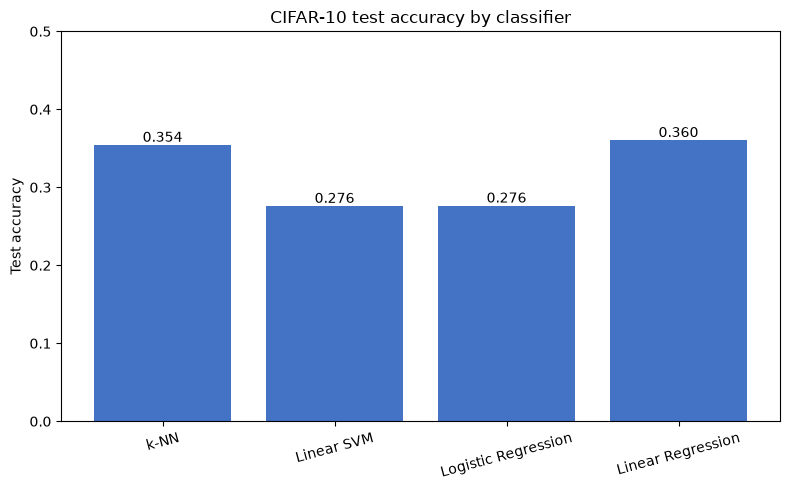

In [7]:
import pandas as pd
res = pd.DataFrame({"Classifier": list(accuracies), "Test accuracy": [round(v, 4) for v in accuracies.values()]})
print(res.to_string(index=False))

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
bars = plt.bar(res["Classifier"], res["Test accuracy"], color="#4472C4")
plt.bar_label(bars, fmt="%.3f"); plt.ylabel("Test accuracy"); plt.ylim(0, 0.5)
plt.title("CIFAR-10 test accuracy by classifier"); plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

## Discussion

On raw CIFAR-10 pixels these classic linear classifiers are limited, which is expected: a single
linear boundary (or nearest-neighbour vote in pixel space) cannot capture the visual structure that
convolutional networks exploit. k-NN is the strongest of the four because it is non-parametric and
can carve out irregular regions, while the linear models (SVM, logistic, least-squares regression)
land in a similar, lower range. These results form the baseline that the convolutional architectures
in Assignment 2 improve on substantially.